In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [43]:
dataset_path = "iris.csv"

df = pd.read_csv(dataset_path, header=None, names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width', 'Species'])

X = df.iloc[:, :4].values
Y = df.iloc[:, 4].values

target = list()

for i in range(len(Y)):
    if Y[i] == "Iris-setosa":
        target.append(1)
    else:
        target.append(0)

target = np.array(target)

random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.80 * len(X))

train_X, train_Y = X[indices[:split]], target[indices[:split]]
test_X, test_Y = X[indices[split:]], target[indices[split:]]

In [44]:
def sigmoid(x):
    return 1 / ( 1 + np.exp(-x) ) 

weights = np.zeros(train_X.shape[1])
bias = 0
learning_rate = 0.01
epochs = 1000
losses = list()

for _ in range(epochs):
    global weights, bias, learning_rate
    linear_model = train_X.dot(weights) + bias
    y_prediction = sigmoid(linear_model)

    loss = -np.mean(
        train_Y * np.log(y_prediction + 1e9) 
        + 
        (1 - train_Y) * np.log(1 - y_prediction + 1e9)
    )
    losses.append(loss)

    dw = train_X.T.dot((y_prediction - train_Y)) / len(train_Y)
    db = sum(y_prediction - train_Y) / len(train_Y)

    weights -= learning_rate * dw
    bias -= learning_rate * db

In [51]:
def predict(x):
    global weights, bias
    linear_model = np.dot(x, weights) + bias 
    probability = sigmoid(linear_model)

    return 1 if probability >= 0.6 else 0

y_prediction = [predict(x) for x in test_X]

In [75]:
TP = FN = TN = FP = 0

for i in range(len(test_X)):
    if test_Y[i] == 1 and y_prediction[i] == 1:
        TP += 1
    elif test_Y[i] == 1 and y_prediction[i] == 0:
        FN += 1
    elif test_Y[i] == 0 and y_prediction[i] == 0:
        TN += 1
    elif test_Y[i] == 0 and y_prediction[i] == 1:
        FP += 1

matrix = [
    [TN, FP],
    [FN, TP]
]

accuracy = ( TP + TN ) / (TP + TN + FP + FN)

print("Confusion Matrix : ", matrix)
print("Accuracy of the model : ", accuracy)

Confusion Matrix :  [[20, 0], [0, 10]]
Accuracy of the model :  1.0


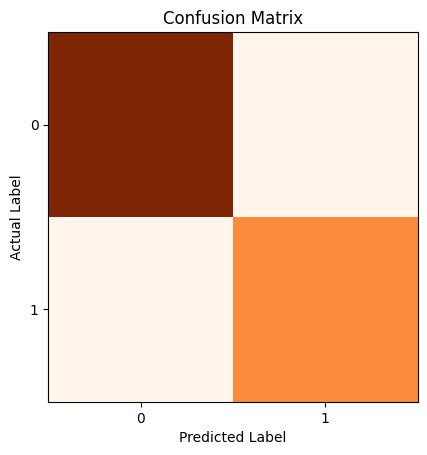

In [77]:
plt.imshow(np.array(matrix), cmap="Oranges")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.xticks([0, 1])
plt.yticks([0, 1])

plt.show()

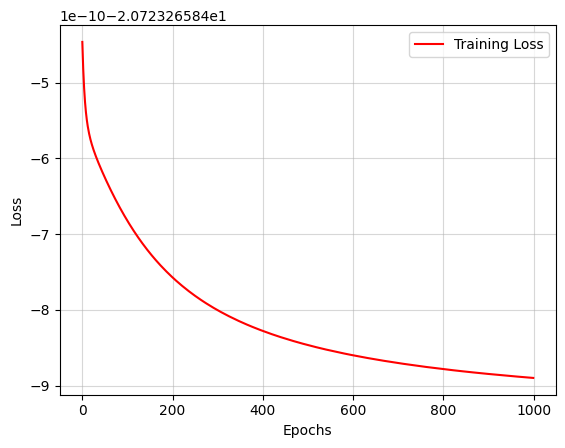

In [78]:
plt.plot(losses,label="Training Loss", markevery=100, color = "red")
plt.grid(alpha = 0.5)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [83]:
print("Enter new values")
sl = float(input("Enter sepal length : "))
sw = float(input("Enter sepal width : "))
pl = float(input("Enter petal length : "))
pw = float(input("Enter petal width : "))

test_point = [sl,sw,pl,pw]

pred = predict(test_point)

if pred == 1:
    print("It is Iris-setosa")
else:
    print("It is not Iris-setosa")

Enter new values


Enter sepal length :  5.0
Enter sepal width :  3.0
Enter petal length :  3.2
Enter petal width :  1.0


It is not Iris-setosa
